<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [4]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [6]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"


In [7]:
df = pd.read_csv(file_path)

In [8]:
df.head(5)

,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,Under 18 years old,"Employed, full-time",Remote,Apples,Hobby,Primary/elementary school,Books / Physical media,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
2,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
3,4,I am learning to code,18-24 years old,"Student, full-time",NaN,Apples,NaN,Some college/university study without earning ...,"Other online resources (e.g., videos, blogs, f...",Stack Overflow;How-to videos;Interactive tutorial,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
4,5,I am a developer by profession,18-24 years old,"Student, full-time",NaN,Apples,NaN,"Secondary school (e.g. American high school, G...","Other online resources (e.g., videos, blogs, f...",Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too short,Easy,NaN,NaN



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [10]:
## Write your code here
df_scatter = (
    df[["Age", "JobSatPoints_6"]]
    .dropna()
    .copy()
)

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 67
}

df_scatter["Age_numeric"] = df_scatter["Age"].map(age_mapping)

df_scatter = df_scatter.dropna(subset=["Age_numeric"])

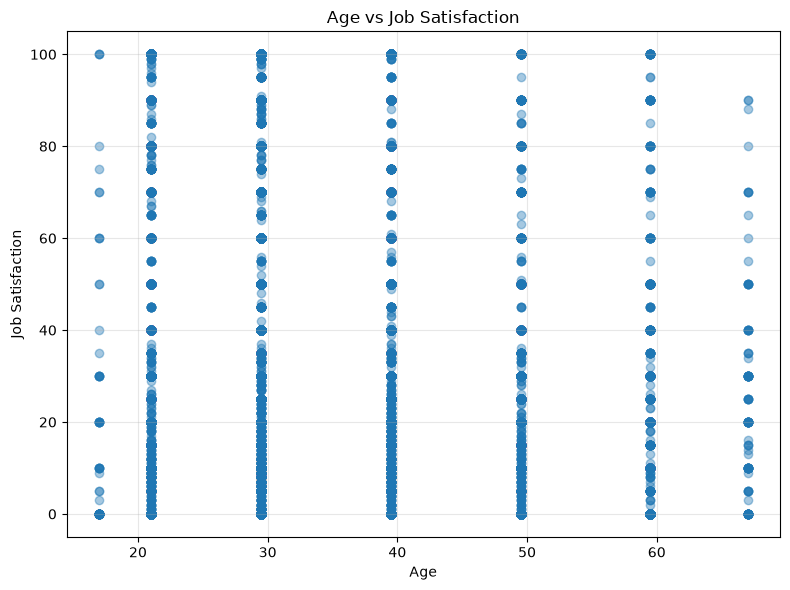

In [11]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_scatter["Age_numeric"],
    df_scatter["JobSatPoints_6"],
    alpha=0.4
)

plt.title("Age vs Job Satisfaction")
plt.xlabel("Age")
plt.ylabel("Job Satisfaction")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [13]:
## Write your code here
df_scatter = (
    df[["ConvertedCompYearly", "JobSatPoints_6"]]
    .dropna()
    .copy()
)

df_scatter["ConvertedCompYearly"] = pd.to_numeric(
    df_scatter["ConvertedCompYearly"],
    errors="coerce"
)

df_scatter = df_scatter.dropna(subset=["ConvertedCompYearly"])

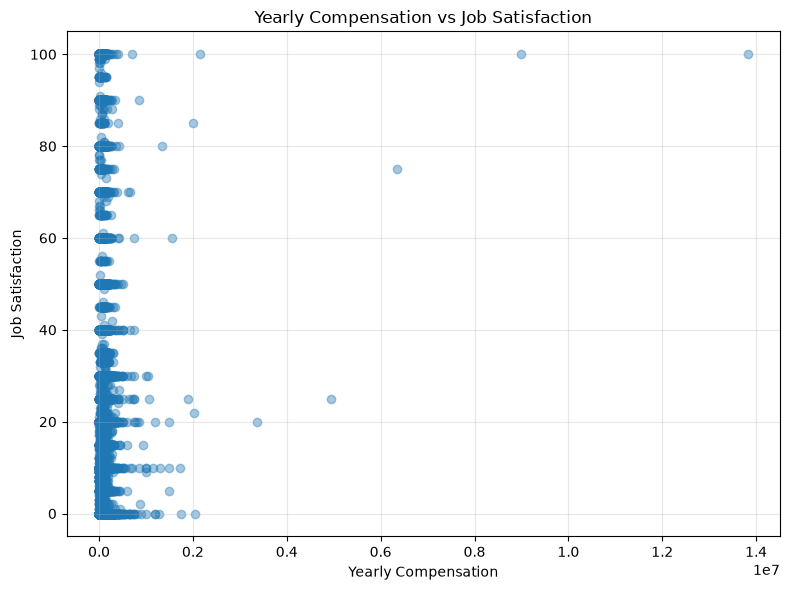

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_scatter["ConvertedCompYearly"],
    df_scatter["JobSatPoints_6"],
    alpha=0.4
)

plt.title("Yearly Compensation vs Job Satisfaction")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [15]:
## Write your code here
df_scatter = (
    df[["Age", "JobSatPoints_6"]]
    .dropna()
    .copy()
)
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 67
}

df_scatter["Age_numeric"] = df_scatter["Age"].map(age_mapping)

df_scatter = df_scatter.dropna(subset=["Age_numeric"])


In [16]:
import numpy as np

x = df_scatter["Age_numeric"]
y = df_scatter["JobSatPoints_6"]

slope, intercept = np.polyfit(x, y, 1)
trendline = slope * x + intercept

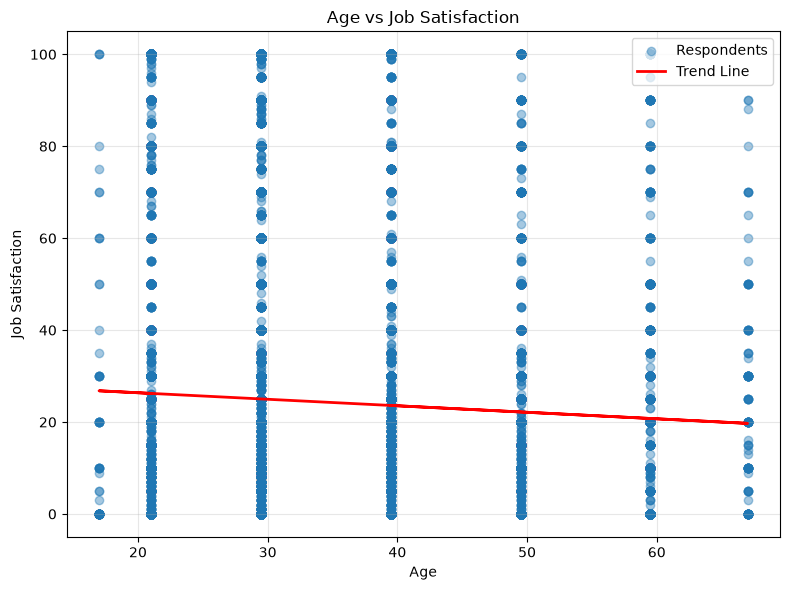

In [17]:
plt.figure(figsize=(8,6))

plt.scatter(
    x,
    y,
    alpha=0.4,
    label="Respondents"
)

plt.plot(
    x,
    trendline,
    color="red",
    linewidth=2,
    label="Trend Line"
)

plt.title("Age vs Job Satisfaction")
plt.xlabel("Age")
plt.ylabel("Job Satisfaction")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [18]:
## Write your code here
df_scatter = (
    df[["Age", "YearsCodePro"]]
    .dropna()
    .copy()
)

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 67
}

df_scatter["Age_numeric"] = df_scatter["Age"].map(age_mapping)

df_scatter["YearsCodePro"] = (
    df_scatter["YearsCodePro"]
    .replace({
        "Less than 1 year": 0,
        "More than 50 years": 51
    })
)

df_scatter["YearsCodePro"] = pd.to_numeric(
    df_scatter["YearsCodePro"],
    errors="coerce"
)

df_scatter = df_scatter.dropna(
    subset=["Age_numeric", "YearsCodePro"]
)


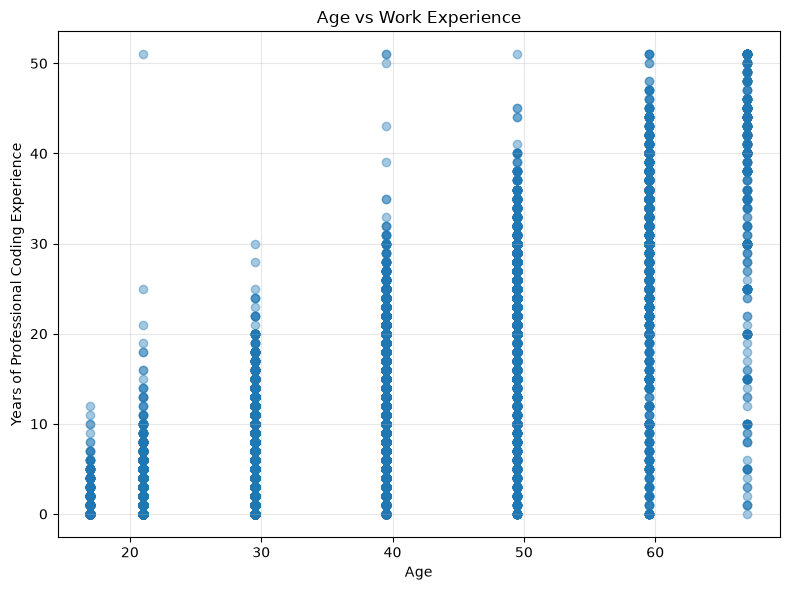

In [19]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_scatter["Age_numeric"],
    df_scatter["YearsCodePro"],
    alpha=0.4
)

plt.title("Age vs Work Experience")
plt.xlabel("Age")
plt.ylabel("Years of Professional Coding Experience")

plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [20]:
## Write your code here
df_bubble = (
    df[["ConvertedCompYearly", "JobSatPoints_6", "Age"]]
    .copy()
)

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 67
}

df_bubble["Age_numeric"] = df_bubble["Age"].map(age_mapping)

df_bubble["ConvertedCompYearly"] = pd.to_numeric(
    df_bubble["ConvertedCompYearly"],
    errors="coerce"
)

df_bubble["JobSatPoints_6"] = pd.to_numeric(
    df_bubble["JobSatPoints_6"],
    errors="coerce"
)

df_bubble = df_bubble.dropna(
    subset=[
        "ConvertedCompYearly",
        "JobSatPoints_6",
        "Age_numeric"
    ]
)

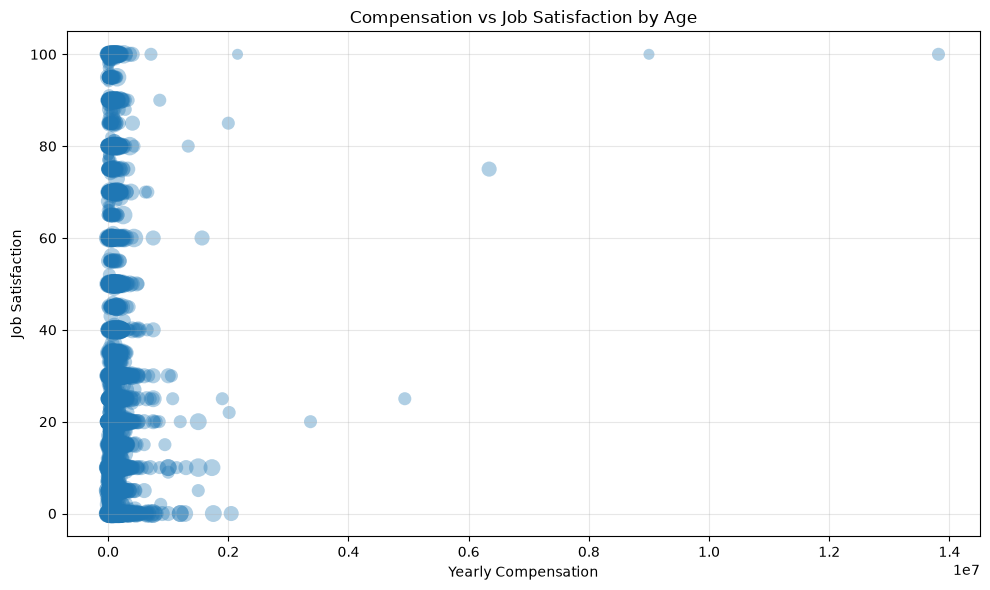

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df_bubble["ConvertedCompYearly"],
    df_bubble["JobSatPoints_6"],
    s=df_bubble["Age_numeric"] * 3,
    alpha=0.35,
    edgecolors="none"
)

plt.title("Compensation vs Job Satisfaction by Age")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [22]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

df_plot = (
    df[["LanguageHaveWorkedWith", "JobSatPoints_6"]]
    .dropna()
    .copy()
)

df_plot["LanguageHaveWorkedWith"] = (
    df_plot["LanguageHaveWorkedWith"]
    .str.split(";")
)

df_plot = df_plot.explode("LanguageHaveWorkedWith")

df_plot["LanguageHaveWorkedWith"] = (
    df_plot["LanguageHaveWorkedWith"]
    .str.strip()
)

In [23]:
language_sat = (
    df_plot
    .groupby("LanguageHaveWorkedWith", as_index=False)["JobSatPoints_6"]
    .mean()
)

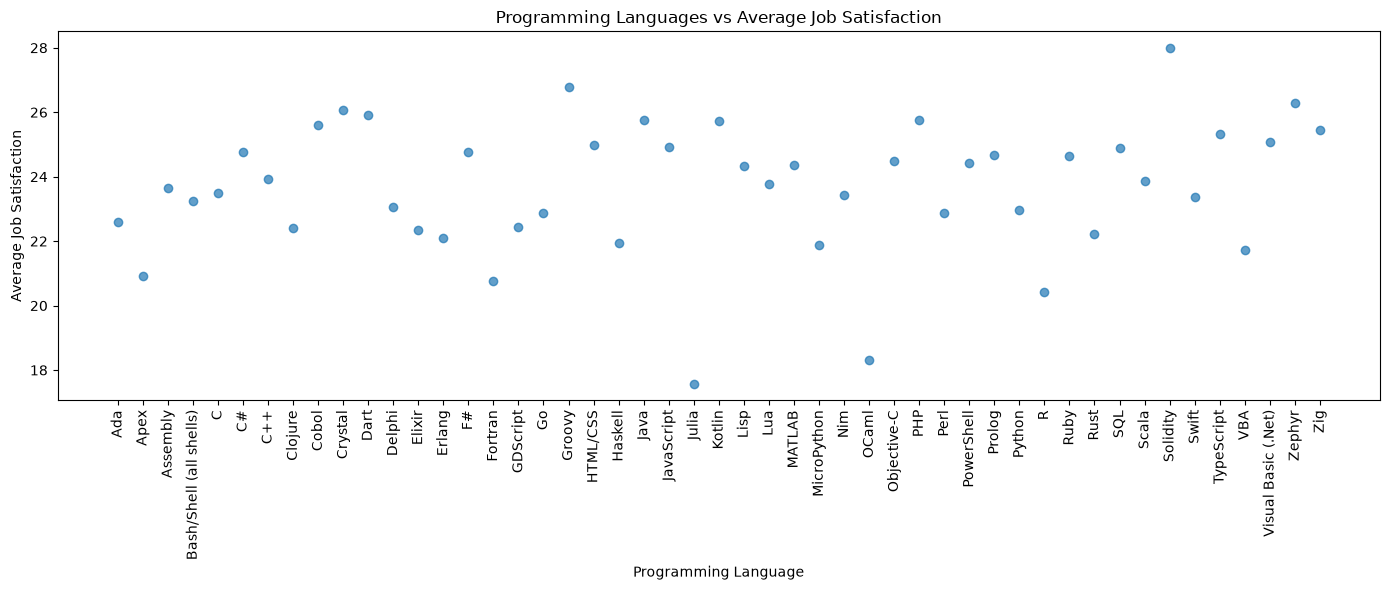

In [24]:
plt.figure(figsize=(14, 6))

plt.scatter(
    language_sat["LanguageHaveWorkedWith"],
    language_sat["JobSatPoints_6"],
    alpha=0.7
)

plt.xticks(rotation=90)

plt.title("Programming Languages vs Average Job Satisfaction")
plt.xlabel("Programming Language")
plt.ylabel("Average Job Satisfaction")

plt.tight_layout()
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


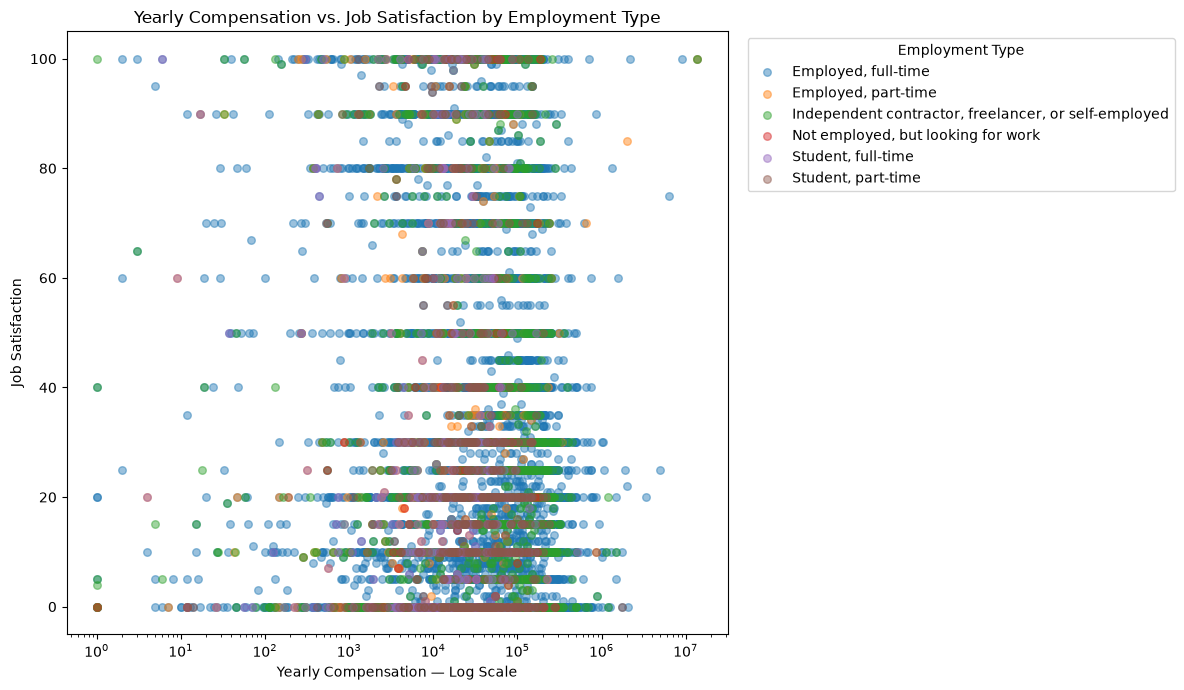

In [25]:
## Write your code here

import pandas as pd
import matplotlib.pyplot as plt

# 1. Seleccionar columnas y crear un DataFrame independiente
df_plot = (
    df[["ConvertedCompYearly", "JobSatPoints_6", "Employment"]]
    .dropna()
    .copy()
)

# 2. Convertir variables numéricas
numeric_cols = ["ConvertedCompYearly", "JobSatPoints_6"]

df_plot[numeric_cols] = df_plot[numeric_cols].apply(
    pd.to_numeric,
    errors="coerce"
)

df_plot = df_plot.dropna(subset=numeric_cols)

# 3. Eliminar compensaciones no válidas para la escala logarítmica
df_plot = df_plot[df_plot["ConvertedCompYearly"] > 0].copy()

# 4. Separar las respuestas múltiples de Employment
df_plot["Employment"] = df_plot["Employment"].str.split(";")
df_plot = df_plot.explode("Employment")

df_plot["Employment"] = df_plot["Employment"].str.strip()

# 5. Mantener los tipos de empleo con más observaciones
top_employment = (
    df_plot["Employment"]
    .value_counts()
    .head(6)
    .index
)

df_plot = df_plot[
    df_plot["Employment"].isin(top_employment)
].copy()

# 6. Crear el scatter plot
fig, ax = plt.subplots(figsize=(12, 7))

for employment_type, group in df_plot.groupby("Employment"):
    ax.scatter(
        group["ConvertedCompYearly"],
        group["JobSatPoints_6"],
        label=employment_type,
        alpha=0.45,
        s=30
    )

ax.set_xscale("log")

ax.set_title(
    "Yearly Compensation vs. Job Satisfaction by Employment Type"
)
ax.set_xlabel("Yearly Compensation — Log Scale")
ax.set_ylabel("Job Satisfaction")
ax.legend(
    title="Employment Type",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [26]:
## Write your code here
import pandas as pd
import matplotlib.pyplot as plt

age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29.5,
    "35-44 years old": 39.5,
    "45-54 years old": 49.5,
    "55-64 years old": 59.5,
    "65 years or older": 67
}

df_plot = (
    df[["YearsCodePro", "Age", "Country"]]
    .dropna()
    .copy()
)

df_plot["YearsCodePro"] = (
    df_plot["YearsCodePro"]
    .replace({
        "Less than 1 year": 0,
        "More than 50 years": 51
    })
    .pipe(pd.to_numeric, errors="coerce")
)

df_plot["Age_numeric"] = df_plot["Age"].map(age_mapping)

df_plot = (
    df_plot
    .dropna(subset=["YearsCodePro", "Age_numeric"])
    .loc[lambda data: data["YearsCodePro"] <= data["Age_numeric"]]
    .copy()
)

top_countries = (
    df_plot["Country"]
    .value_counts()
    .head(5)
    .index
)

df_plot = (
    df_plot[df_plot["Country"].isin(top_countries)]
    .copy()
)

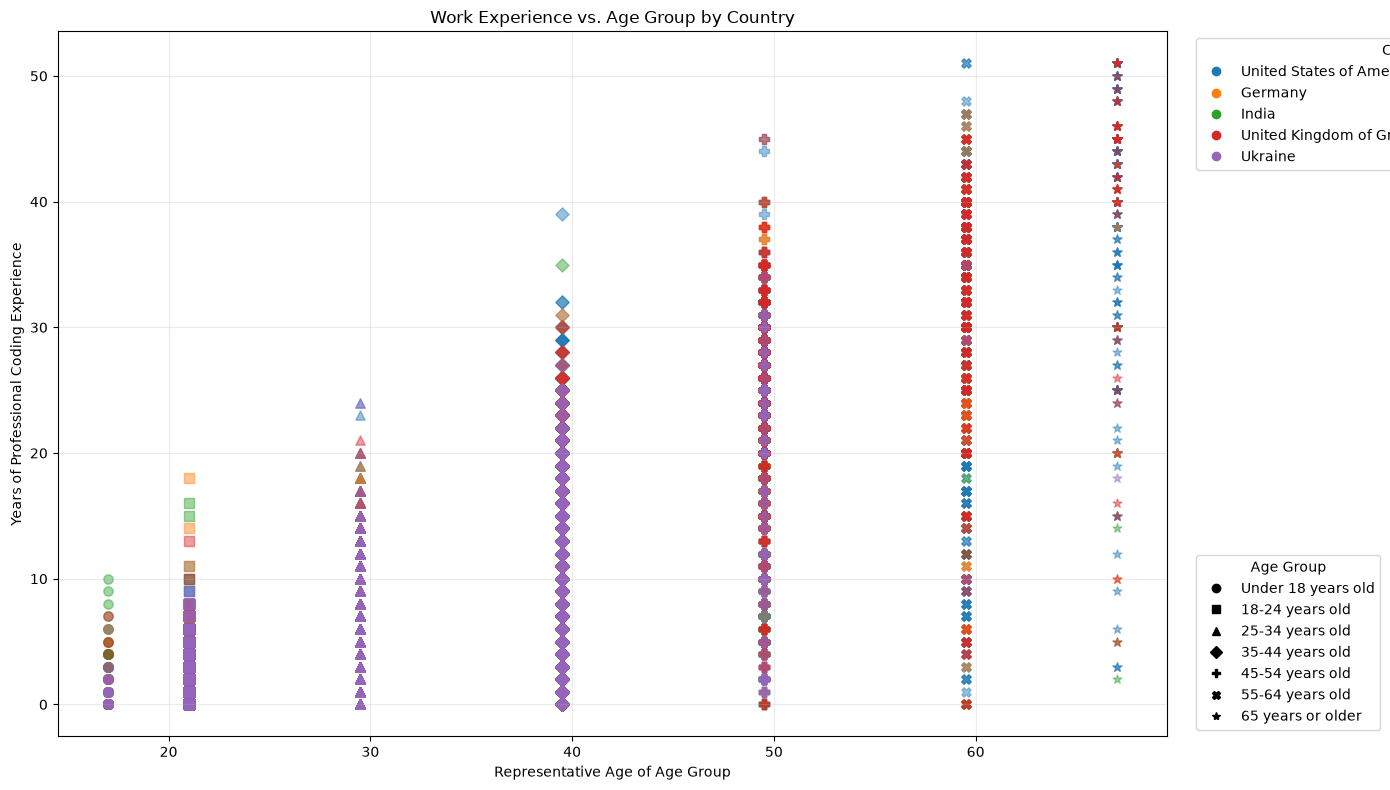

In [27]:
marker_mapping = {
    "Under 18 years old": "o",
    "18-24 years old": "s",
    "25-34 years old": "^",
    "35-44 years old": "D",
    "45-54 years old": "P",
    "55-64 years old": "X",
    "65 years or older": "*"
}

country_colors = {
    country: color
    for country, color in zip(
        top_countries,
        plt.cm.tab10.colors
    )
}

fig, ax = plt.subplots(figsize=(14, 8))

for age_group, marker in marker_mapping.items():
    age_data = df_plot[df_plot["Age"] == age_group]

    for country in top_countries:
        group = age_data[age_data["Country"] == country]

        ax.scatter(
            group["Age_numeric"],
            group["YearsCodePro"],
            color=country_colors[country],
            marker=marker,
            alpha=0.45,
            s=45
        )

country_handles = [
    plt.Line2D(
        [0],
        [0],
        marker="o",
        linestyle="",
        color=country_colors[country],
        label=country
    )
    for country in top_countries
]

age_handles = [
    plt.Line2D(
        [0],
        [0],
        marker=marker,
        linestyle="",
        color="black",
        label=age_group
    )
    for age_group, marker in marker_mapping.items()
]

country_legend = ax.legend(
    handles=country_handles,
    title="Country",
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

ax.add_artist(country_legend)

ax.legend(
    handles=age_handles,
    title="Age Group",
    loc="lower left",
    bbox_to_anchor=(1.02, 0)
)

ax.set_title("Work Experience vs. Age Group by Country")
ax.set_xlabel("Representative Age of Age Group")
ax.set_ylabel("Years of Professional Coding Experience")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
